# Part 1

### Dataset Creation

In [49]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)

In [50]:
print("Dimension de X :", X.shape)
print("Dimension de y :", y.shape)

Dimension de X : (1000, 2)
Dimension de y : (1000,)


* Input: The input of the classifier has 2 dimensions (x1, x2), representing the two coordinates of each point in 2D space. This corresponds to the shape (1000, 2) of the feature matrix X.
* Output: The output of the classifier has 1 dimension, which is a binary value (0 or 1) indicating the class of each point. This corresponds to the shape (1000,) of the label vector y.

### Data visualization

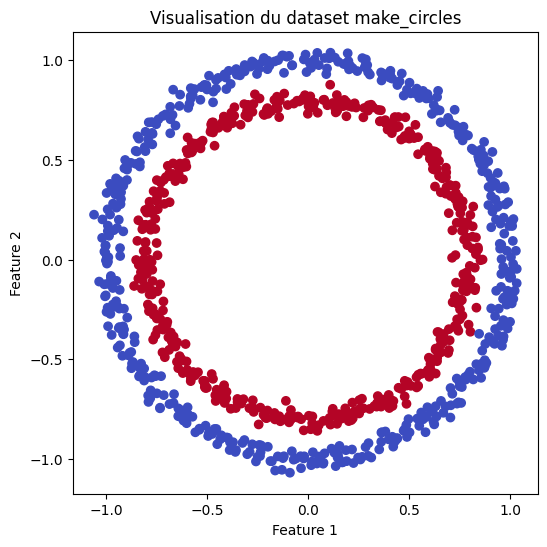

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
plt.title("Visualisation du dataset make_circles")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

This dataset requires a non-linear function to separate its classes.

The dataset generated using make_circles() consists of two concentric circles, where one class is located inside the other. Because of this structure, the classes cannot be separated by a straight line (linear decision boundary).

A linear classifier such as logistic regression or a single linear neuron would fail to correctly separate the two classes.


### Splitting the data into training and testing sets

To evaluate the model, the dataset must be divided into:

* Training set (80%) → used to train the model
* Test set (20%) → used to evaluate the model's performance

In [52]:
from sklearn.model_selection import train_test_split

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Display the dimensions
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (800, 2)
Test set shape: (200, 2)


### Creating new model FCNNN

The model will contain one fully connected (Dense) hidden layer with 100 neurons and a sigmoid activation function.

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create the model
model = Sequential()

# Add a fully connected hidden layer with 100 neurons and sigmoid activation
model.add(Dense(100, activation='sigmoid', input_shape=(2,)))

# output layer
model.add(Dense(1, activation='sigmoid'))

### Display a concise summary of the model architecture

In [54]:
model.summary()

Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_109 (Dense)               │ (None, 100)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_110 (Dense)               │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

### Model Compilation
To train the neural network, we must compile the model by specifying:

* Loss function: Binary Cross-Entropy (used for binary classification problems)
* Optimizer: SGD (Stochastic Gradient Descent)
* Metric: Accuracy to evaluate performance

In [55]:
from tensorflow.keras.optimizers import SGD

model.compile(
    loss='binary_crossentropy',
    optimizer=SGD(),
    metrics=['accuracy']
)

### Model Training
We train the neural network for 100 epochs and evaluate its performance on the test dataset.

To display the training progress every 10 epochs, we set verbose=2 (which prints one line per epoch, making it easier to track progress).

In [56]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    verbose=2
)

Epoch 1/100
25/25 - 1s - 51ms/step - accuracy: 0.5000 - loss: 0.7414 - val_accuracy: 0.5000 - val_loss: 0.6999
Epoch 2/100
25/25 - 0s - 11ms/step - accuracy: 0.4875 - loss: 0.6959 - val_accuracy: 0.5000 - val_loss: 0.6941
Epoch 3/100
25/25 - 0s - 10ms/step - accuracy: 0.5013 - loss: 0.6941 - val_accuracy: 0.5150 - val_loss: 0.6941
Epoch 4/100
25/25 - 0s - 8ms/step - accuracy: 0.4825 - loss: 0.6940 - val_accuracy: 0.5200 - val_loss: 0.6941
Epoch 5/100
25/25 - 0s - 8ms/step - accuracy: 0.5088 - loss: 0.6942 - val_accuracy: 0.5150 - val_loss: 0.6941
Epoch 6/100
25/25 - 0s - 8ms/step - accuracy: 0.4863 - loss: 0.6940 - val_accuracy: 0.5200 - val_loss: 0.6941
Epoch 7/100
25/25 - 0s - 8ms/step - accuracy: 0.5088 - loss: 0.6940 - val_accuracy: 0.4550 - val_loss: 0.6942
Epoch 8/100
25/25 - 0s - 9ms/step - accuracy: 0.4762 - loss: 0.6944 - val_accuracy: 0.5100 - val_loss: 0.6941
Epoch 9/100
25/25 - 0s - 9ms/step - accuracy: 0.4762 - loss: 0.6941 - val_accuracy: 0.5150 - val_loss: 0.6941
Epoch 1

## Model Evaluation

### Plot the decision boundary for the training and test sets

2813/2813 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


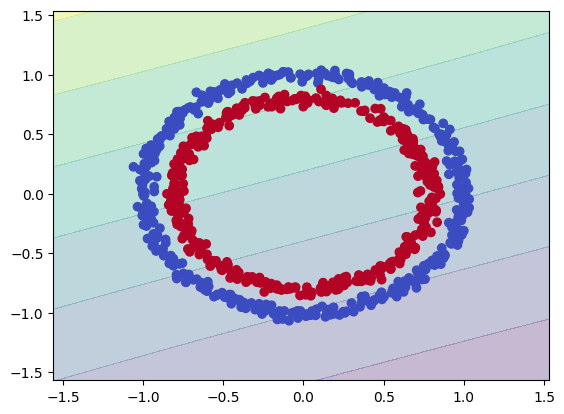

2813/2813 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


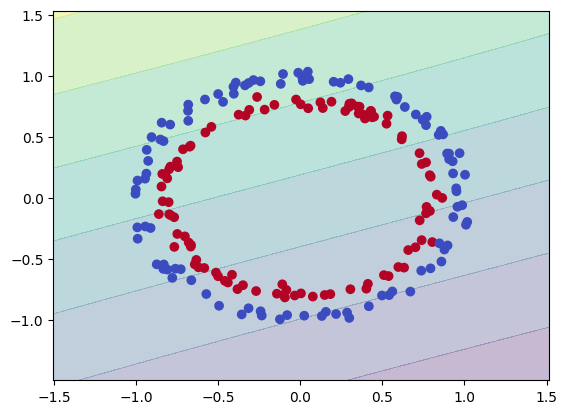

In [57]:
def plot_decision_boundary(model, X, y):

    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    predictions = model.predict(grid)
    predictions = predictions.reshape(xx.shape)

    plt.contourf(xx, yy, predictions, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
    plt.show()

# Training set decision boundary
plot_decision_boundary(model, X_train, y_train)

# Test set decision boundary
plot_decision_boundary(model, X_test, y_test)

### What is the problem with this model?

The base model suffers from underfitting. 

The accuracy bounces randomly between 46% and 53% for the entire second half of training — that is pure random guessing (50/50). The loss stays frozen at ~0.6938 and never meaningfully decreases. This confirms the model is completely stuck and learning nothing.

The decision boundary plots 
Instead of a circle separating the two rings, the model drew diagonal straight lines across the data. That is a linear boundary, which is completely wrong for a circles dataset. The blue and red points are totally mixed up on both train and test, meaning the model cannot separate the two classes at all.

 In short, the model is too shallow and the optimizer too weak to capture the true structure of the data.

### Improve the model

There are 3 improvements to apply:
1. Replace SGD with Adam — Adam adapts the learning rate automatically for each parameter, converges much faster and doesn't get stuck like SGD did.
2. Add more hidden layers — One layer wasn't deep enough to learn the circular boundary. More layers = more capacity to learn complex non-linear shapes.
3. Train longer (more epochs) — Give the model enough time to fully converge.

In [58]:
from tensorflow.keras.optimizers import Adam

# Build a deeper model
model_improved = Sequential([
    Dense(128, activation='relu', input_shape=(2,)),  # 1st hidden layer: more neurons
    Dense(64,  activation='relu'),                    # 2nd hidden layer
    Dense(32,  activation='relu'),                    # 3rd hidden layer
    Dense(1,   activation='sigmoid')                  # output: binary classification
])

# Compile with Adam instead of SGD
model_improved.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_improved.summary()

# Train for more epochs
history_improved = model_improved.fit(
    X_train, y_train,
    epochs=200,
    validation_data=(X_test, y_test),
    verbose=1
)

# Evaluate
train_loss, train_acc = model_improved.evaluate(X_train, y_train, verbose=0)
test_loss,  test_acc  = model_improved.evaluate(X_test,  y_test,  verbose=0)
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test  Accuracy: {test_acc:.4f}")

Model: "sequential_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_111 (Dense)               │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_113 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_114 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,753 (42.00 KB)

 Trainable params: 10,753 (42.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5000 - loss: 0.6888 - val_accuracy: 0.5000 - val_loss: 0.6879
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5000 - loss: 0.6811 - val_accuracy: 0.5000 - val_loss: 0.6815
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5200 - loss: 0.6726 - val_accuracy: 0.5200 - val_loss: 0.6729
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5350 - loss: 0.6586 - val_accuracy: 0.5550 - val_loss: 0.6559
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7312 - loss: 0.6360 - val_accuracy: 0.6900 - val_loss: 0.6198
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7188 - loss: 0.5833 - val_accuracy: 0.9050 - val_loss: 0.5574
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9237 - loss: 0.4807 - val_accuracy: 0.9050 - val_loss: 0.4399
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9812 - loss: 0.3433 - val_accuracy: 0.9950 - 

# Part 2: Multi-Classification

### Create a multi-class dataset

In [59]:
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=1000,
    centers=4,       # number of classes
    n_features=2,
    random_state=42
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 2)
y shape: (1000,)


### Split the dataset into training and testing sets

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (800, 2)
Test set: (200, 2)


### Visualize the data

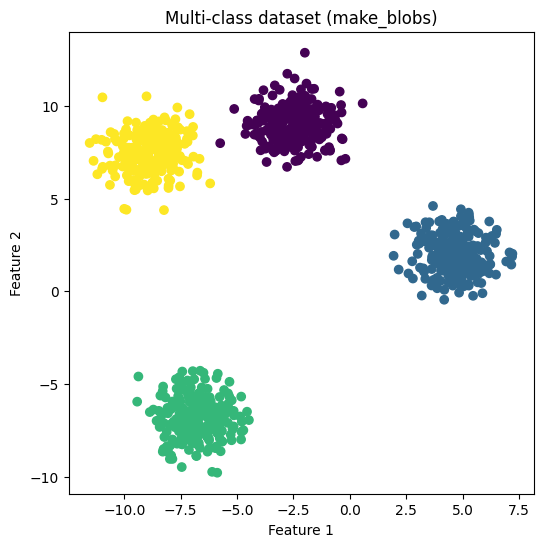

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis')
plt.title("Multi-class dataset (make_blobs)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Does this dataset require a linear or non-linear function?

This dataset can generally be separated using a linear function.

The data generated by make_blobs() forms separate clusters, where each class is concentrated around a center. Because the clusters are well separated, linear decision boundaries (straight lines) can usually divide the classes.

Therefore, a linear classifier is often sufficient to separate the classes in this dataset.

### Propose an FCNN architecture for this classification problem

For multi-class classification (4 classes), a suitable Fully Connected Neural Network (FCNN) architecture can be:

* Input layer: 2 features
* Hidden layer 1: 64 neurons (ReLU activation)
* Hidden layer 2: 32 neurons (ReLU activation)
* Output layer: 4 neurons with Softmax activation

The softmax activation outputs probabilities for the 4 classes.

In [62]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

model = Sequential()

# Hidden layers
model.add(Dense(64, activation='relu', input_dim=2))
model.add(Dense(32, activation='relu'))

# Output layer for 4 classes
model.add(Dense(4, activation='softmax'))

# Compile model
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(0.01),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_115 (Dense)               │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_116 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_117 (Dense)               │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,404 (9.39 KB)

 Trainable params: 2,404 (9.39 KB)

 Non-trainable params: 0 (0.00 B)

* ReLU helps the network learn non-linear patterns.
* Softmax converts the output into probabilities for the 4 classes.
* Sparse categorical crossentropy is used because labels are integers (0–3).

### Train the model

In [63]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    verbose=2
)

Epoch 1/100
25/25 - 1s - 50ms/step - accuracy: 0.9325 - loss: 0.2425 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 2/100
25/25 - 0s - 7ms/step - accuracy: 0.9987 - loss: 0.0054 - val_accuracy: 0.9950 - val_loss: 0.0204
Epoch 3/100
25/25 - 0s - 7ms/step - accuracy: 0.9962 - loss: 0.0090 - val_accuracy: 0.9950 - val_loss: 0.0069
Epoch 4/100
25/25 - 0s - 7ms/step - accuracy: 0.9987 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 2.0231e-04
Epoch 5/100
25/25 - 0s - 7ms/step - accuracy: 0.9975 - loss: 0.0054 - val_accuracy: 1.0000 - val_loss: 2.1714e-04
Epoch 6/100
25/25 - 0s - 7ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 7/100
25/25 - 0s - 7ms/step - accuracy: 0.9975 - loss: 0.0151 - val_accuracy: 0.9950 - val_loss: 0.0165
Epoch 8/100
25/25 - 0s - 7ms/step - accuracy: 0.9962 - loss: 0.0115 - val_accuracy: 1.0000 - val_loss: 0.0041
Epoch 9/100
25/25 - 0s - 7ms/step - accuracy: 0.9987 - loss: 0.0036 - val_accuracy: 0.9950 - val_loss: 0.0080
E

### Display classification metrics

In [64]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict classes
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
print("Confusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Confusion Matrix:
[[49  0  0  0]
 [ 0 41  0  0]
 [ 0  0 53  0]
 [ 0  0  0 57]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        49
           1       1.00      1.00      1.00        41
           2       1.00      1.00      1.00        53
           3       1.00      1.00      1.00        57

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



The matrix is a perfect diagonal, every single value outside the diagonal is 0, meaning the model made zero mistakes across all 200 test samples. Every point from Class 0 was predicted as Class 0, every point from Class 1 as Class 1, and so on. There is no confusion between any pair of classes whatsoever.

Every metric for every class is 1.00 (100%), which means:

* Precision = 1.00 → Every time the model predicted a class, it was right. No false positives at all.
* Recall = 1.00 → The model detected every single sample of each class. No false negatives at all.
* F1-Score = 1.00 → The perfect balance between precision and recall, confirming flawless performance.
* Accuracy = 1.00 → All 200 test predictions were correct.

### Plotting the Decision Boundaries (Training and Test sets)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


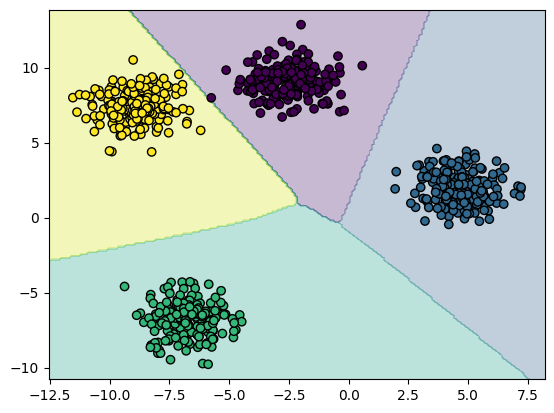

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


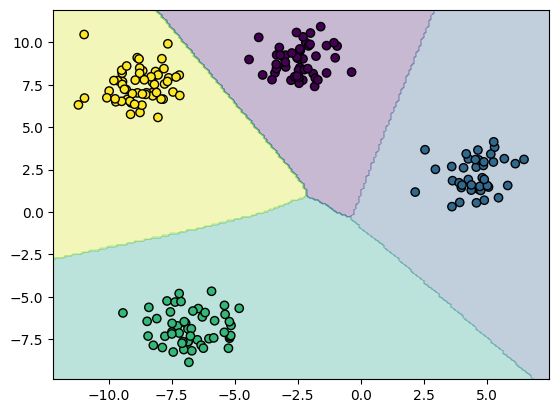

In [65]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y):

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    preds = model.predict(grid)
    preds = np.argmax(preds, axis=1)

    preds = preds.reshape(xx.shape)

    plt.contourf(xx, yy, preds, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k')
    plt.show()

plot_decision_boundary(model, X_train, y_train)
plot_decision_boundary(model, X_test, y_test)

The decision boundaries are straight lines dividing the space into 4 colored regions, and each cluster sits perfectly inside its own region with no points crossing into the wrong zone. This is exactly what was expected because make_blobs creates linearly separable classes — the model only needs straight boundaries to separate them.

### Study the impact of dataset size on accuracy
We will train the model with different dataset sizes and observe the evolution of accuracy.

In [68]:
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import tensorflow as tf

sample_sizes = [100, 200, 400, 600, 800, 1000]
accuracies = []

for size in sample_sizes:

    X, y = make_blobs(
        n_samples=size,
        centers=4,
        n_features=2,
        random_state=42
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation='relu', input_dim=2),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(4, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(X_train, y_train, epochs=50, verbose=0)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    accuracies.append(acc)

Plotting the accuracy curve

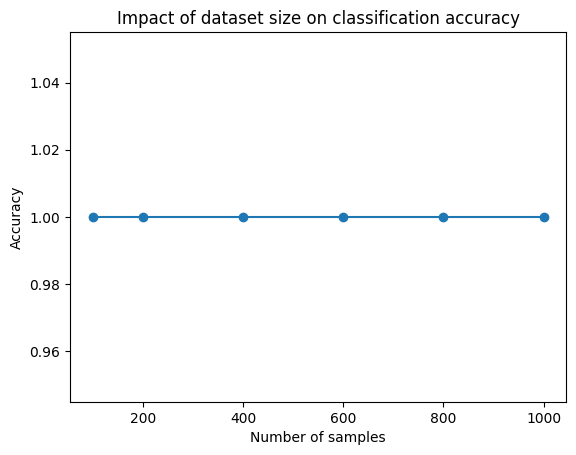

In [69]:
plt.plot(sample_sizes, accuracies, marker='o')
plt.xlabel("Number of samples")
plt.ylabel("Accuracy")
plt.title("Impact of dataset size on classification accuracy")
plt.show()

The accuracy stays flat at 1.00 (100%) across all sample sizes from 100 to 1000. This means that even with only 100 samples, the model already achieves perfect classification.